<a href="https://colab.research.google.com/github/ayesha0859/DL/blob/main/DL3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Part a) Neural Network Design

In [1]:
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
model = keras.Sequential([
    layers.Dense(units=64, activation='relu', input_shape=[10]),
    layers.Dense(units=32, activation='relu'),
    layers.Dense(units=1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

None


### Part b) Plotting the Model

In [4]:
from tensorflow.keras.utils import plot_model

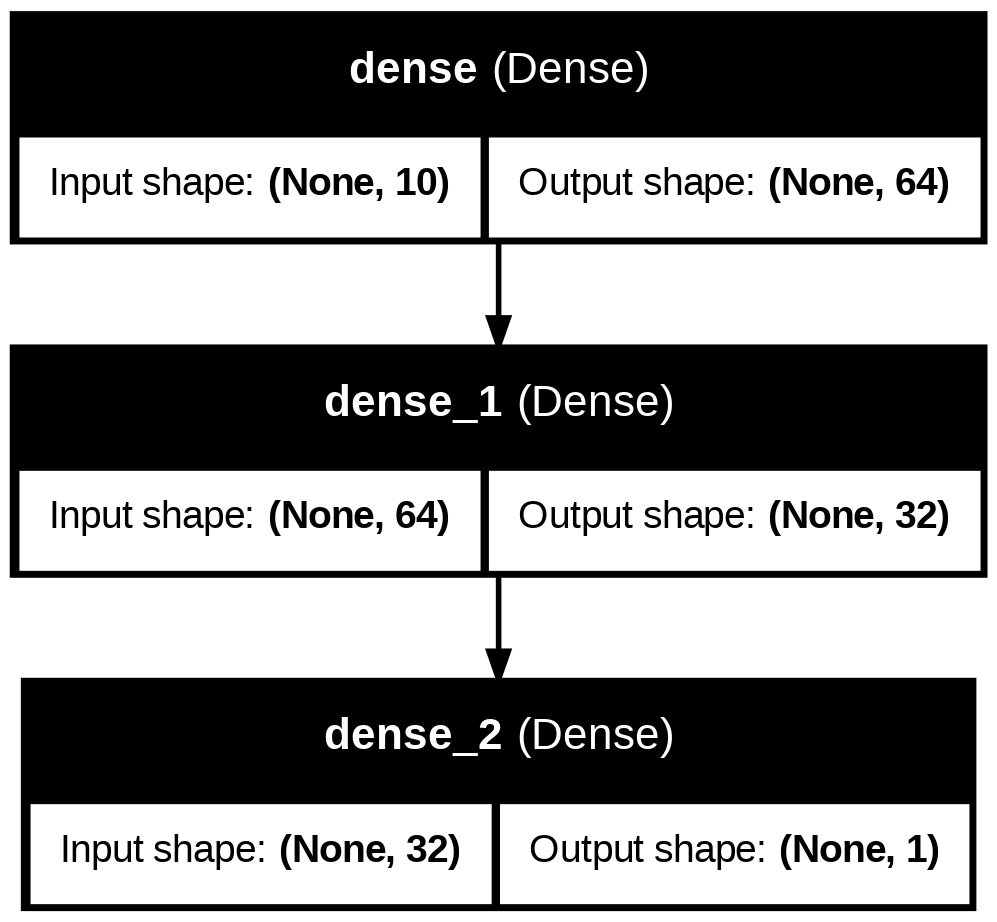

In [5]:
plot_model(model, show_shapes=True, show_layer_names=True)

### Part c) Training the Model with Dummy Data

In [13]:
import numpy as np

# Generate dummy data
x_dummy = np.random.rand(1000, 10)  # 1000 samples, 10 features
y_dummy = np.random.randint(0, 2, 1000) # 1000 binary labels (0 or 1) (meaning:0 se start, 2 se kam, size=1000)

In [14]:
history = model.fit(
    x_dummy,
    y_dummy,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

print(history.history)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4975 - loss: 0.6953 - val_accuracy: 0.5200 - val_loss: 0.6951
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5250 - loss: 0.6902 - val_accuracy: 0.5150 - val_loss: 0.6987
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5238 - loss: 0.6899 - val_accuracy: 0.5300 - val_loss: 0.7003
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5750 - loss: 0.6840 - val_accuracy: 0.5050 - val_loss: 0.7012
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5537 - loss: 0.6830 - val_accuracy: 0.5250 - val_loss: 0.7028
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5763 - loss: 0.6810 - val_accuracy: 0.5200 - val_loss: 0.7043
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5387 - loss: 0.6813 - val_accuracy: 0.5000 - val_loss: 0.7046
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5763 - loss: 0.6802 - val_accuracy: 0.5200 - val_loss

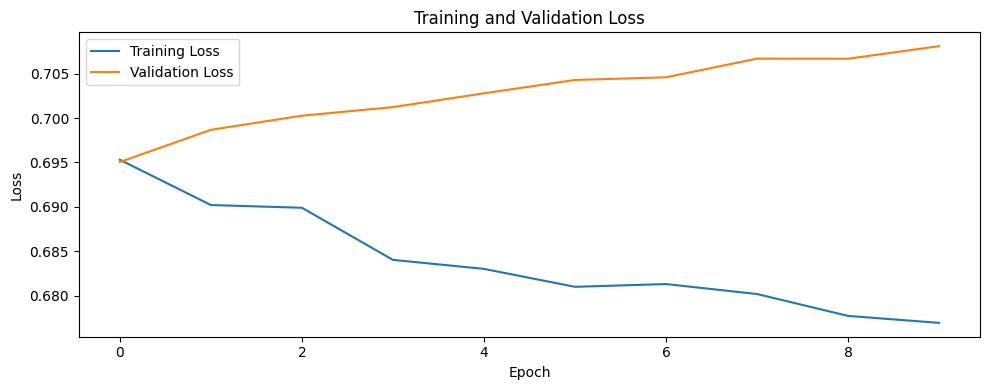

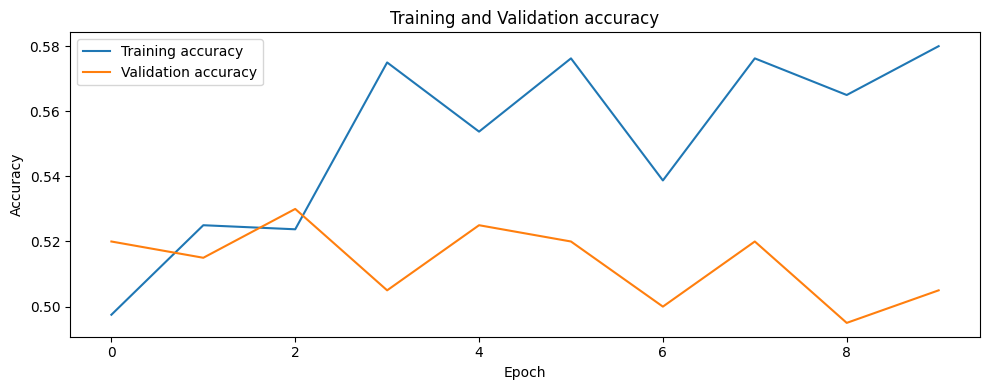

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation accuracy')
plt.tight_layout()
plt.show()

### Part d) Training the Model with a Real Dataset

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

bc = load_breast_cancer()
X = bc.data  # Features
y = bc.target # Target labels (0 or 1)

# Select the first 10 features to match the model's input shape
# Your model has input_shape=[10], meaning it expects 10 features.
X = X[:, :10]  #All rows but only first 10 columns(features)

print(f"Loaded dataset shape: X={X.shape}, y={y.shape}")

Loaded dataset shape: X=(569, 10), y=(569,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing data shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training data shape: X_train=(455, 10), y_train=(455,)
Testing data shape: X_test=(114, 10), y_test=(114,)


In [8]:
history_data = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

print(history_data.history)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.4879 - loss: 16.9983 - val_accuracy: 0.6228 - val_loss: 8.4857
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5165 - loss: 3.2395 - val_accuracy: 0.6228 - val_loss: 0.8644
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7143 - loss: 0.6544 - val_accuracy: 0.8070 - val_loss: 0.4070
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8176 - loss: 0.4020 - val_accuracy: 0.8772 - val_loss: 0.2764
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8374 - loss: 0.3845 - val_accuracy: 0.8947 - val_loss: 0.2627
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8549 - loss: 0.3407 - val_accuracy: 0.9123 - val_loss: 0.2570
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8220 - loss: 0.3640 - val_accuracy: 0.8947 - val_loss: 0.2565
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8725 - loss: 0.3257 - val_accuracy: 0.9298 - v

In [9]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8772 - loss: 0.2510 

Test Loss: 0.2510
Test Accuracy: 0.8772


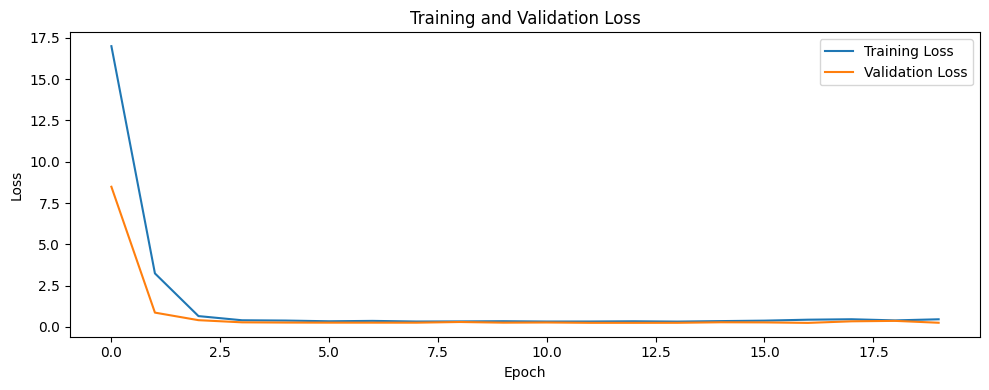

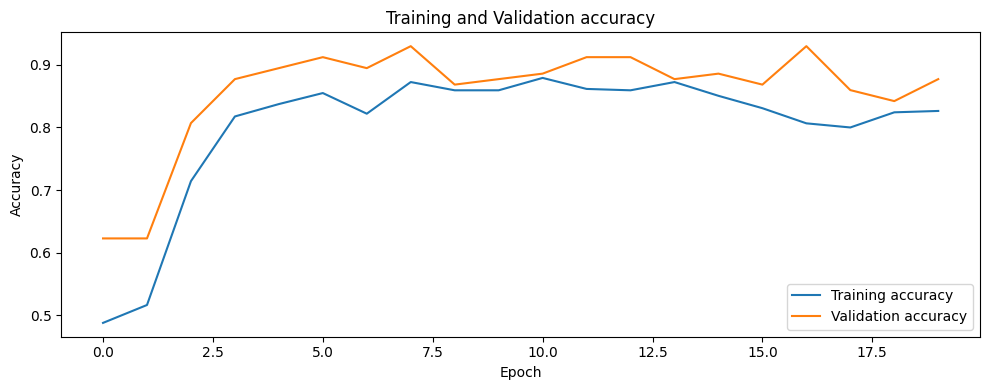

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(history_data.history['loss'], label='Training Loss')
plt.plot(history_data.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_data.history['accuracy'], label='Training accuracy')
plt.plot(history_data.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation accuracy')
plt.tight_layout()
plt.show()